#### When does regularization fail?

Excessive Penalty (Underfitting) - Perform hyperparameter tuning using Grid Search

Unscaled Features - Always standardize

Choosing the Wrong Penalty for the Data - Use Elastic Net regularization


After SMOTE you should check for multicolinarity

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_train = pd.read_csv("/Users/sukitharathnayake/CodeRepo/ST4035/Data/hacide_train.csv")
df_test = pd.read_csv("/Users/sukitharathnayake/CodeRepo/ST4035/Data/hacide_test.csv")

In [3]:
print(df_train.shape)
print(df_test.shape)

(1000, 3)
(250, 3)


In [4]:
df_train.head()

,cls,x1,x2
0,0,0.200798,0.678038
1,0,0.016620,1.576558
2,0,0.228725,-0.559534
3,0,0.126379,-0.093814
4,0,0.600821,-0.298395


In [5]:
percentages = df_train['cls'].value_counts(normalize=True) * 100
print(percentages)

cls
0    98.0
1     2.0
Name: proportion, dtype: float64


In [6]:
X = df_train.drop('cls', axis=1)
y = df_train['cls']

In [7]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

learn link functions

In [8]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_oversampled, y_overampled = ros.fit_resample(X_train, y_train)

In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

In [10]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Fit and resample the training data
X_undersampled, y_undersampled = rus.fit_resample(X_train, y_train)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,roc_curve,classification_report

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       195
           1       1.00      0.20      0.33         5

    accuracy                           0.98       200
   macro avg       0.99      0.60      0.66       200
weighted avg       0.98      0.98      0.97       200

[[195   0]
 [  4   1]]


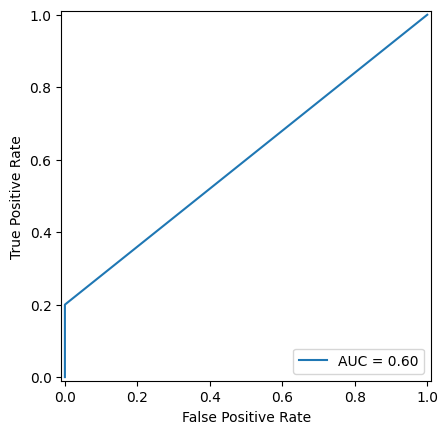

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# y_scores = model's predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)

# Plotting using the dedicated display class
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score)
display.plot()
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,roc_curve,classification_report

model = LogisticRegression()

model.fit(X_undersampled, y_undersampled)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.84      0.91       195
           1       0.14      1.00      0.24         5

    accuracy                           0.84       200
   macro avg       0.57      0.92      0.57       200
weighted avg       0.98      0.84      0.89       200

[[163  32]
 [  0   5]]


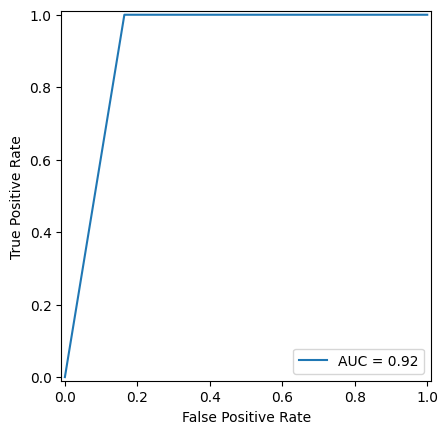

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# y_scores = model's predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)

# Plotting using the dedicated display class
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score)
display.plot()
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,roc_curve,classification_report

model = LogisticRegression()

model.fit(X_oversampled, y_overampled)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.81      0.89       195
           1       0.10      0.80      0.17         5

    accuracy                           0.81       200
   macro avg       0.55      0.81      0.53       200
weighted avg       0.97      0.81      0.87       200

[[158  37]
 [  1   4]]


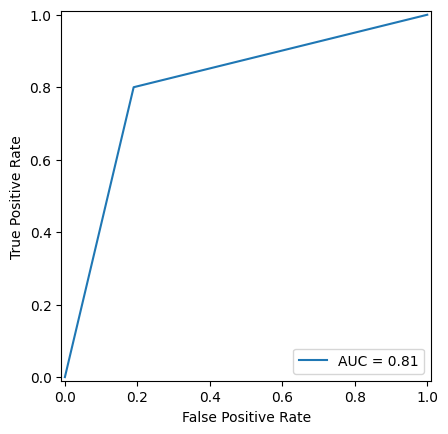

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# y_scores = model's predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)

# Plotting using the dedicated display class
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score)
display.plot()
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,roc_curve,classification_report

model = LogisticRegression()

model.fit(X_sm, y_sm)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91       195
           1       0.11      0.80      0.20         5

    accuracy                           0.83       200
   macro avg       0.55      0.82      0.55       200
weighted avg       0.97      0.83      0.89       200

[[163  32]
 [  1   4]]


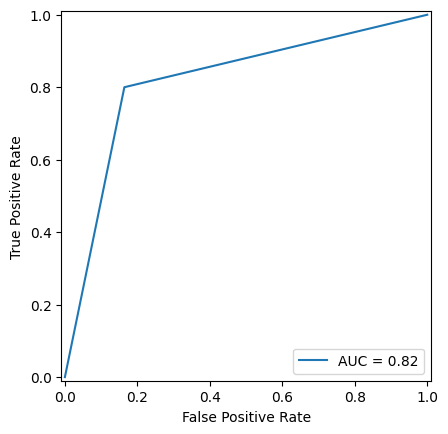

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# y_scores = model's predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)

# Plotting using the dedicated display class
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score)
display.plot()
plt.show()